In [10]:
import festim as F


my_model = F.Simulation()

import numpy as np

my_model.mesh = F.MeshFromVertices(np.linspace(0, 8e-3, num=15000))

tungsten = F.Material(
    id=1,
    D_0=1.5e-07,  # m2/s
    E_D=0.265,  # eV
    S_0=2.7e24,
    E_S=1.14,
    borders=[0,5e-3],
    thermal_cond=173,  # W/mK
)

copper = F.Material(
    id=2,
    D_0=6.6e-7,
    E_D=0.387,
    S_0=3.14e24,
    E_S=0.572,
    borders=[5e-3, 6e-3],
    thermal_cond=350,
)

cucrzr = F.Material(
	id=3, 
	D_0=4.8e-7, 
	E_D=0.42, 
	S_0=4.27e23, 
	E_S=0.39,
	borders=[6e-3, 8e-3],
	thermal_cond=320
)

my_model.materials = [tungsten, copper, cucrzr]

In [11]:
w_density = 6.3e28  # atom/m3  
copper_density = 9.2e28
cucrzr_density = 9.2e28  

damage_percent = 0.01 # 0.1-2 dpa/fpy W neutronic damage

trap_W_1 = F.Trap( 
	k_0 = [1.5e-7/((1.1e-10)**2 * 6 * w_density),6.6e-7 / ((3.6e-10)**2 * 1 * copper_density),4.8e-7 / ((3.6e-10)**2 * 1 * cucrzr_density)],
	E_k= [0.265,0.387,0.418],
	p_0=[1.2397e13,5.0926e12,7.3472e12],
	E_p=[0.83,0.5,0.53], 
	density = [w_density*0.00118,copper_density*0.00005,3.7e24],
	materials = [tungsten,copper,cucrzr]
)
            
trap_W_2 = F.Trap(
	k_0 = 1.5e-7/((1.1e-10)**2 * 6 * w_density),
	E_k= 0.265, 
	p_0=1.2397e13,
	E_p=0.97,
	density = w_density*0.000722,
	materials = [tungsten]
)

trap_W_3 = F.Trap(
	k_0=1.5e-7/(1.1e-10**2 * 6 * w_density),
	E_k=0.265,
	p_0=1e13,
	E_p=1.51, # change to 2.05 when necessary
	density = damage_percent*w_density,
	materials = tungsten
) 
my_model.traps = [trap_W_1, trap_W_2, trap_W_3]

In [12]:
my_model.T = F.HeatTransferProblem(transient=False)

my_model.boundary_conditions = [
    F.ImplantationDirichlet(surfaces=1, phi=0.23e24, R_p=1.1e-9, D_0=1.5e-07, E_D=0.265), # mean depth may be too low, maybe order of magnitude higher
    F.DirichletBC(surfaces=2, value=0, field=0),
    F.FluxBC(surfaces=1, value=10e6, field="T"),
   # F.DirichletBC(surfaces=1, value=1273, field="T"),
    F.DirichletBC(surfaces=2, value=480, field="T"), # Set coolant temp to 573K as 473K messes it up for some reason
]

my_model.sources = [ 
		F.Source(value=28.8e6, volume=1, field='T'), # Neutronic heating W: 1.3-28.8 MW/m3
		F.Source(value=8.1e6, volume=[2, 3, 4], field='T'), # Neutronic heating Cu & CuCrZr: 0.3-8.1 MW/m3
]
		
# Stepsize
my_model.dt = None


# Settings
my_model.settings = F.Settings(
    absolute_tolerance=1e14, relative_tolerance=1e-04, final_time=3.2e7, 
    chemical_pot=True, traps_element_type="DG", transient = False
)

conc_coolant = F.TotalVolume("0", volume = 4)

derived_quantities = F.DerivedQuantities(
    [conc_coolant]
)

results_folder = "PFC_retention_profiles/DIVMON" # CHANGE END OF FILENAME

txt_export = F.TXTExport(
    field='0',
    filename=results_folder + '/solute_ss.txt',
    )

my_model.exports = [derived_quantities, txt_export]

my_model.initialise()
my_model.run()

Defining variational problem heat transfers
Solving stationary heat equation
Defining initial values
Defining variational problem
Defining source terms
Defining boundary conditions
Solving steady state problem...
Solved problem in 0.50 s


/Users/fj1628/anaconda3/envs/festim-env/lib/python3.11/site-packages/festim/exports/derived_quantities/derived_quantities.py:129: DeprecationWarning: The current derived_quantities title style will be deprecated in a future release, please use show_units=True instead
  warnings.warn(


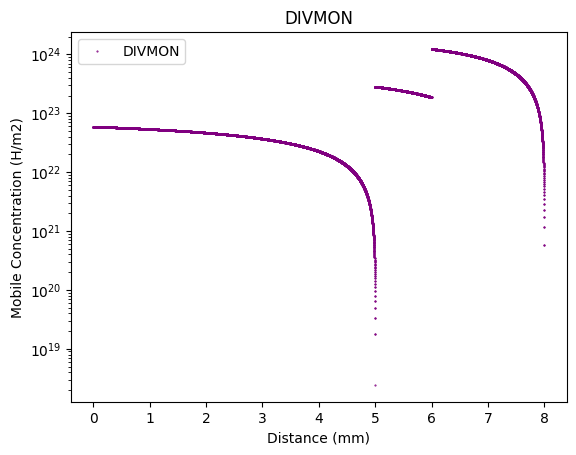

In [13]:
import matplotlib.pyplot as plt

solute_data = np.loadtxt(results_folder + '/solute_ss.txt', delimiter=',', dtype = 'float', skiprows = 1 )
dist = solute_data[:, 0] * 1000
solute = solute_data[:, 1]

plt.plot(dist, solute, 'o', markersize=0.5, markerfacecolor = 'purple', markeredgecolor = 'purple', label='DIVMON')
plt.yscale("log")
plt.ylabel('Mobile Concentration (H/m2)')
plt.xlabel('Distance (mm)')
plt.title("DIVMON")
plt.legend()
